In [1]:
import pandas as pd
train = pd.read_csv('./data/train.csv')
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


Quick distribution check

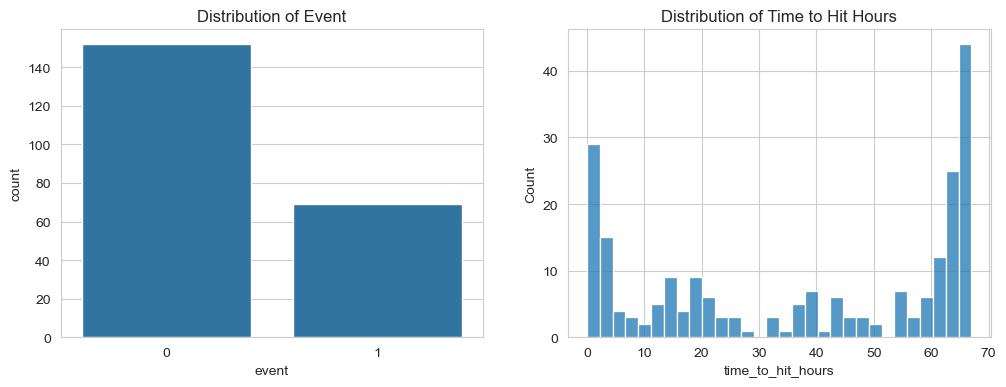

In [2]:
TARGETS = ['time_to_hit_hours', 'event']
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
# plot the distribution of the binary variable 'event' as a column chart
sns.countplot(x='event', data=train, ax=axes[0])
axes[0].set_title('Distribution of Event')
# plot the distribution of the continuous variable 'time_to_hit_hours' as a histogram
sns.histplot(train['time_to_hit_hours'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of Time to Hit Hours')
plt.show()

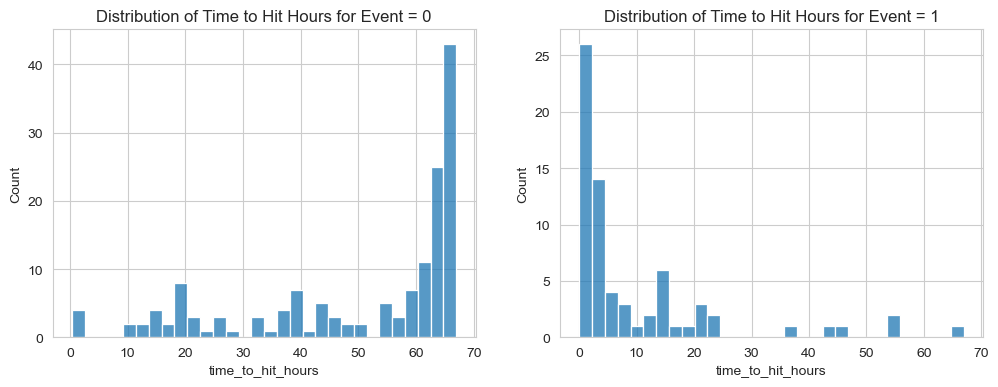

In [3]:
# create a subplot of the distribution of the continuous variable 'time_to_hit_hours' for each category of the binary variable 'event'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.histplot(train[train['event'] == 0]['time_to_hit_hours'], bins=30, ax=axes[0])
axes[0].set_title('Distribution of Time to Hit Hours for Event = 0')
sns.histplot(train[train['event'] == 1]['time_to_hit_hours'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of Time to Hit Hours for Event = 1')
plt.show()

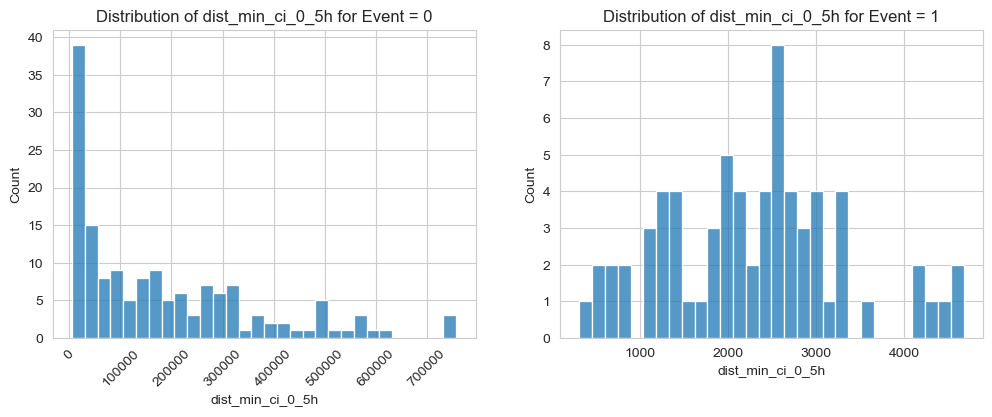

In [4]:
# plot the distribution of the continuous variable 'dist_min_ci_0_5h' conditional on the binary variable 'event'
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.histplot(train[train['event'] == 0]['dist_min_ci_0_5h'], bins=30, ax=axes[0])
axes[0].set_title('Distribution of dist_min_ci_0_5h for Event = 0')
# rotate the x-axis labels for better readability
axes[0].tick_params(axis='x', rotation=45)
sns.histplot(train[train['event'] == 1]['dist_min_ci_0_5h'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of dist_min_ci_0_5h for Event = 1')
plt.show()

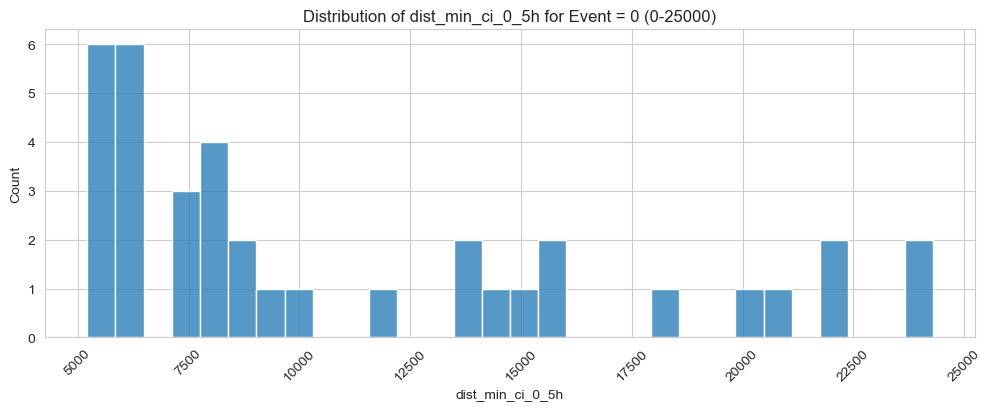

In [5]:
# plot the distribution of the continuous variable 'dist_min_ci_0_5h' only when the value is between 0 and 25000, conditional on event = 0
fig, axes = plt.subplots(figsize=(12, 4))
sns.histplot(train[(train['event'] == 0) & (train['dist_min_ci_0_5h'] >= 0) & (train['dist_min_ci_0_5h'] <= 25000)]['dist_min_ci_0_5h'], bins=30, ax=axes)
axes.set_title('Distribution of dist_min_ci_0_5h for Event = 0 (0-25000)')
# rotate the x-axis labels for better readability
axes.tick_params(axis='x', rotation=45)
plt.show()

In [6]:
# create a numerical summary of the continuous variable 'closing_speed_m_per_h' for each category of the binary variable 'event'
summary = train.groupby('event')['closing_speed_m_per_h'].describe()
print('=== Summary of Closing Speed by Event ===')
print(summary)
# show the proportion of zeroes in the continuous variable 'closing_speed_m_per_h' for each category of the binary variable 'event'
zero_proportion = train.groupby('event')['closing_speed_m_per_h'].apply(lambda x: (x == 0).mean())
print('\n=== Proportion of Zeroes in Closing Speed by Event ===')
print(zero_proportion)

=== Summary of Closing Speed by Event ===
       count      mean        std        min  25%  50%  75%         max
event                                                                  
0      152.0  0.081931   9.072713 -51.397494  0.0  0.0  0.0   93.922570
1       69.0  6.293863  46.101181 -42.625315  0.0  0.0  0.0  354.120897

=== Proportion of Zeroes in Closing Speed by Event ===
event
0    0.953947
1    0.840580
Name: closing_speed_m_per_h, dtype: float64


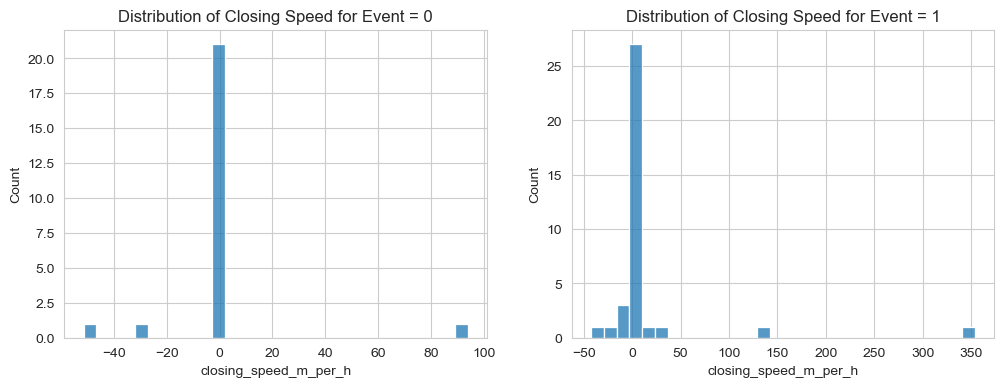

In [7]:
# plot the distribution of the continuous variable 'closing_speed_m_per_h' conditional on the binary variable 'event', filtered by low_temporal_resolution_0_5h = 0
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
sns.histplot(train[(train['event'] == 0) & (train['low_temporal_resolution_0_5h'] == 0)]['closing_speed_m_per_h'], bins=30, ax=axes[0])
axes[0].set_title('Distribution of Closing Speed for Event = 0')
sns.histplot(train[(train['event'] == 1) & (train['low_temporal_resolution_0_5h'] == 0)]['closing_speed_m_per_h'], bins=30, ax=axes[1])
axes[1].set_title('Distribution of Closing Speed for Event = 1')
plt.show()

In [8]:
# print the proportion of 'event' = 1, filtered by 'closing_speed_m_per_h' > 0
proportion = train[(train['closing_speed_m_per_h'] > 0)]['event'].mean()
print(f'Proportion of Event = 1 when Closing Speed > 0: {proportion}')
# print the proportion of 'event' = 1 with no filters, rounded to two decimal places
overall_proportion = train['event'].mean()
print(f'Overall Proportion of Event = 1: {overall_proportion:.2f}')
# print the proportion of 'event' = 1, filtered by 'closing_speed_m_per_h' > 0 and 'low_temporal_resolution_0_5h' = 0
filtered_proportion = train[(train['closing_speed_m_per_h'] > 0) & (train['low_temporal_resolution_0_5h'] == 0)]['event'].mean()
print(f'Proportion of Event = 1 when Closing Speed > 0 and Low Temporal Resolution = 0: {filtered_proportion}')
# print the proportion of 'event' = 1, filtered by 'closing_speed_m_per_h' < 0 and 'low_temporal_resolution_0_5h' = 0
negative_filtered_proportion = train[(train['closing_speed_m_per_h'] < 0) & (train['low_temporal_resolution_0_5h'] == 0)]['event'].mean()
print(f'Proportion of Event = 1 when Closing Speed < 0 and Low Temporal Resolution = 0: {negative_filtered_proportion}')

Proportion of Event = 1 when Closing Speed > 0: 0.75
Overall Proportion of Event = 1: 0.31
Proportion of Event = 1 when Closing Speed > 0 and Low Temporal Resolution = 0: 0.75
Proportion of Event = 1 when Closing Speed < 0 and Low Temporal Resolution = 0: 0.5


In [12]:
# print the proportion of 'event', filtered by 'low_temporal_resolution_0_5h'
proportion_low_temporal = train[train['low_temporal_resolution_0_5h'] == 1]['event'].mean()
proportion_high_temporal = train[train['low_temporal_resolution_0_5h'] == 0]['event'].mean()
print(f'Proportion of Event = 1 when Low Temporal Resolution = 1: {proportion_low_temporal}')
print(f'Proportion of Event = 1 when Low Temporal Resolution = 0: {proportion_high_temporal}')

Proportion of Event = 1 when Low Temporal Resolution = 1: 0.20496894409937888
Proportion of Event = 1 when Low Temporal Resolution = 0: 0.6
